# 2. Understanding the Raw Data

## 2.1 Data Exploration and Dataset Inspection

We are going to explore three different climate datasets with varying formats and structures, each serving a specific purpose in our geospatial data processing pipeline.

### Import libraries

In [20]:
# Import necessary libraries for geospatial data processing and handling

# Standard library imports
import os                    # Provides functions for interacting with the operating system (file paths, environment variables)
import glob                  # Used for pathname pattern matching to find files matching a specified pattern
from pathlib import Path     # Object-oriented interface for filesystem paths (more modern alternative to os.path)

# Geospatial and climate data libraries
import cfgrib                # Library specifically designed for reading GRIB files (common format for meteorological data)
import cftime                # Provides datetime-like objects for working with calendar systems (especially important for climate data)
import xarray as xr          # Powerful library for working with labeled multi-dimensional arrays (essential for geospatial data handling)

# Suppress warnings to clean up the output
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

### Define data paths

In [21]:
# The demo data lives in <repo root>/data/module-00 (see README, "Demo Data")
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIR = root / "data" / "module-00"

# Define directory paths for different climate datasets
# These paths point to the locations where various climate reanalysis and model data are stored

ERA5_dir = DATA_DIR / "ERA5"

CERRA_dir = DATA_DIR / "CERRA"

CMIP_dir = DATA_DIR / "CMIP6"

### Inspecting datasets

In [22]:
print("#### ERA5 Air temperature #### \n")

# Open the ERA5 dataset containing 2-meter temperature data from the surface
# ERA5 data is stored in GRIB format
ds_era5 = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-2m_temperature.grib")
print(ds_era5)  
print("\n")     


print("#### CERRA Relative humidity #### \n")

# Create a time coder specifically designed for handling CF (Climate Forecast) datetime conventions
# use_cftime=True ensures proper handling of calendar systems
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

# Open the CERRA dataset containing 2-meter relative humidity data
# CERRA data is also in GRIB format, so we specify engine="cfgrib" to properly read it
# decode_times=time_coder ensures that time coordinates are correctly interpreted using CF conventions
ds_cerra = xr.open_dataset(CERRA_dir / "CERRA-AIFTraining-M0-2m_relative_humidity.grib", 
                          decode_times=time_coder, 
                          engine="cfgrib")
print(ds_cerra)  
print("\n")     


print("#### CMIP6 Air temperature #### \n")

# Open the CMIP6 dataset containing daily air temperature data
# CMIP6 data is stored in NetCDF format, so we specify engine="netcdf4"
# This dataset contains historical simulations from the EC-Earth3-CC climate model
# The filename indicates it covers the year 2000 with daily temporal resolution
ds_cmip6 = xr.open_dataset(CMIP_dir / "tas_day_EC-Earth3-CC_historical_r1i1p1f1_gr_20000101-20001231.nc", 
                          engine="netcdf4")
print(ds_cmip6)  
print("\n")     

# These three operations demonstrate the heterogeneity of the data sources:
# - ERA5 (GRIB format, surface temperature)
# - CERRA (GRIB format, surface relative humidity) 
# - CMIP6 (NetCDF format, daily temperature simulations)
# Each dataset needs to be processed and harmonized before combining 

Ignoring index file '/home/jvedri/Desktop/climate-data-ai-anemoi/data/ERA5/ERA5-AIFTraining-M0-2m_temperature.grib.5b7b6.idx' incompatible with GRIB file


#### ERA5 Air temperature #### 

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    t2m         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-21T12:00 GRIB to CDM+CF via cfgrib-0.9.1...


#### CERRA Relative hum

### Dataset summary
#### ERA5 Air Temperature Dataset

    - Dimensions: 744 time steps (January 2020), 721 latitude points, 1440 longitude points
    - Spatial Resolution: High-resolution global coverage with ~0.25° grid spacing
    - Data Format: GRIB format from ECMWF (European Centre for Medium-Range Weather Forecasts)
    - Variable: 2-meter temperature (t2m) 
    - Temporal Coverage: Daily data with hourly resolution (24 hours × 31 days = 744 time steps)


#### CERRA Relative Humidity Dataset

    - Dimensions: 248 time steps (January 2020), 1069×1069 spatial grid points
    - Spatial Resolution: Regional high-resolution grid (1069×1069 points)
    - Data Format: GRIB format from Norrköping (Swedish Meteorological and Hydrological Institute)
    - Variable: 2-meter relative humidity (r2)
    - Coordinate System: Latitude/longitude coordinates stored as 2D arrays (y, x dimensions)

#### CMIP6 Air Temperature Dataset

    - Dimensions: 366 time steps (full year 2000), 256 latitude points, 512 longitude points  
    - Data Format: NetCDF format from CMIP6 climate model simulations
    - Variable: Daily air temperature (tas) 
    - Temporal Coverage: Annual data with daily resolution

## 2.2 Inspecting Data Structure: Coordinates, Variables & Metadata

### Why This Matters

When working with geospatial datasets, understanding the underlying structure is the foundation for accurate analysis. In this section, we'll explore how data is organized in terms of:
 
1. Coordinate systems (time, latitude, longitude)
2. Variables (temperature, precipitation, etc.)
3. Metadata (descriptive information about data)

This knowledge helps you:

- Select the correct regions and time periods
- Interpret data units correctly
- Handle differences between dataset formats (GRIB vs. NetCDF)

### 2.2.1 Coordinate Systems

Coordinates define where data is located in space and time. In Xarray, they're structured as dimensions that enable precise data slicing. Let's compare ERA5 and CERRA datasets.
#### ERA5

In [23]:
# Print general coordinate information for the ERA5 dataset
# Coordinates define the dimensions and metadata of the dataset's variables
print("#### General coords #### \n")
print(ds_era5.coords)  # Display all coordinate variables (latitude, longitude, time, etc.)
print("\n")          

# Print detailed information about the time coordinate specifically
print("#### Time coord #### \n")
print(ds_era5.time)    # Display time coordinate metadata including units, calendar, and dimension info
print("\n")           

# Print the actual time values to understand the temporal range and format
print("#### Time values #### \n")
print(ds_era5.time.values[0:5])  # Display first 5 time values to examine the temporal resolution and format
print("\n")

# Print calendar information to understand the time reference system
print("#### Calendar #### \n")
calendar = ds_era5.time.dt.calendar
print(calendar)

# These commands help us understand:
# 1. What coordinate variables exist in the ERA5 dataset (latitude, longitude, time)
# 2. The structure and metadata of the time coordinate system
# 3. The actual temporal values to confirm the data spans the expected period

#### General coords #### 

Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...


#### Time coord #### 

<xarray.DataArray 'time' (time: 744)> Size: 6kB
array(['2020-01-01T00:00:00.000000000', '2020-01-01T01:00:00.000000000',
       '2020-01-01T02:00:00.000000000', ..., '2020-01-31T21:00:00.000000000',
       '2020-01-31T22:00:00.000000000', '2020-01-31T23:00:00.000000000'],
      shape=(744,), dtype='datetime64[ns]')
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
At

#### CERRA coordinates

In [24]:
# Print general coordinate information for the CERRA dataset
# Coordinates define the dimensions and metadata of the dataset's variables
print("#### General coords #### \n")
print(ds_cerra.coords)  # Display all coordinate variables (latitude, longitude, time, etc.)
print("\n")            

# Print detailed information about the time coordinate specifically
print("#### Time coord #### \n")
print(ds_cerra.time)    # Display time coordinate metadata including units, calendar, and dimension info
print("\n")           

# Print the actual time values to understand the temporal range and format
print("#### Time values #### \n")
print(ds_cerra.time.values[0:5])  # Display first 5 time values to examine the temporal resolution and format
print("\n")

# These commands help us understand:
# 1. What coordinate variables exist in the CERRA dataset (latitude, longitude, time)
# 2. The structure and metadata of the time coordinate system
# 3. The actual temporal values to confirm the data spans the expected period
# 4. Differences in coordinate structure compared to ERA5 dataset for proper data harmonization

#### General coords #### 

Coordinates:
  * time               (time) object 2kB 2020-01-01 00:00:00 ... 2020-01-31 2...
    valid_time         (time) object 2kB ...
    latitude           (y, x) float64 9MB ...
    longitude          (y, x) float64 9MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...


#### Time coord #### 

<xarray.DataArray 'time' (time: 248)> Size: 2kB
array([cftime.DatetimeProlepticGregorian(2020, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2020, 1, 1, 3, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2020, 1, 1, 6, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeProlepticGregorian(2020, 1, 31, 15, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2020, 1, 31, 18, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2020, 1, 31, 21, 0, 0, 0, has_year_zero=True)],
      shape=(248,), dtype=object)
Coordinates:
  *

#### Key Differences:
| Feature          | ERA5                          | CERRA                         |
|------------------|-------------------------------|-------------------------------|
| **Time Format**  | `datetime64[ns]` (standard)   | `cftime` objects (region-specific) |
| **Spatial Grid** | 1D coordinates                | 2D coordinates (`y, x`)       |
| **Temporal Steps** | 1-hour intervals            | 3-hour intervals |

### 2.2.2 Variables: Data Structure and Units

Variables hold the actual data values

In [25]:
# Print all variable names in the ERA5 dataset
# This displays the complete list of data variables contained within the dataset
print("#### All variables #### \n")
print(ds_era5.data_vars)  # Show all data variables
print("\n")

# Print detailed information about the specific temperature variable
# This shows metadata and structure of the 2-meter temperature variable specifically
print("#### Variable info #### \n")
print(ds_era5.t2m)    # Display comprehensive information about the t2m (2-meter temperature) variable
print("\n")

# Print actual data values to examine the structure and content
# Shows a small subset of the 3D temperature data array (time, latitude, longitude)
print("#### Variable data #### \n")
print(ds_era5.t2m.values[0:5,0:5,0:5])  # Display first 5 values along each dimension to examine data structure
print("\n")

# These commands help us understand:
# 1. What data variables are available in the ERA5 dataset
# 2. The specific structure and metadata of the temperature variable
# 3. The actual data array structure with dimensions (time, latitude, longitude)
# 4. Verify that the data contains expected temperature values and proper array dimensions
# This information is crucial for understanding the data content before performing operations like data transformation, normalization, or combining with other datasets

#### All variables #### 

Data variables:
    t2m      (time, latitude, longitude) float32 3GB ...


#### Variable info #### 

<xarray.DataArray 't2m' (time: 744, latitude: 721, longitude: 1440)> Size: 3GB
[772450560 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                          

### 2.2.3 Metadata
Metadata provides crucial context about how data was generated. Let's compare formats:

#### Global attributes

In [26]:
# Print all attributes (metadata) from the ERA5 dataset
# Attributes contain important information about the data source, processing, and conventions
print("#### All variables GRIB #### \n")
print(ds_era5.attrs)  # Display comprehensive metadata including GRIB format information,
                      # data source details, and CF (Climate Forecast) conventions
print("\n")

# Print all attributes (metadata) from the CMIP6 dataset  
# Attributes contain model-specific information and simulation details
print("#### All variables nc #### \n")
print(ds_cmip6.attrs)  # Display metadata including model information, experiment details,
                       # temporal resolution, and CF conventions for NetCDF format
print("\n")

# These commands help us understand:
# 1. The metadata differences between GRIB (ERA5) and NetCDF (CMIP6) data formats
# 2. Source information, processing history, and data conventions for each dataset
# 3. Model-specific attributes that are important for understanding the data context
# 4. Conventions and standards used (CF-1.7) that ensure interoperability between datasets

#### All variables GRIB #### 

{'GRIB_edition': 1, 'GRIB_centre': 'ecmf', 'GRIB_centreDescription': 'European Centre for Medium-Range Weather Forecasts', 'GRIB_subCentre': 0, 'Conventions': 'CF-1.7', 'institution': 'European Centre for Medium-Range Weather Forecasts', 'history': '2026-09-21T12:00 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.24.2 with {"source": "../../data/ERA5/ERA5-AIFTraining-M0-2m_temperature.grib", "filter_by_keys": {}, "encode_cf": ["parameter", "time", "geography", "vertical"]}'}


#### All variables nc #### 

{'Conventions': 'CF-1.7 CMIP-6.2', 'activity_id': 'CMIP', 'branch_method': 'standard', 'branch_time_in_child': np.float64(0.0), 'branch_time_in_parent': np.float64(0.0), 'contact': 'cmip6-data@ec-earth.org', 'creation_date': '2020-12-11T03:03:39Z', 'data_specs_version': '01.00.31', 'experiment': 'all-forcing simulation of the recent past', 'experiment_id': 'historical', 'external_variables': 'areacella', 'forcing_index': np.int32(1), 'frequency': 'day', 'fu

#### Specific attributes

In [27]:
# Print attribute information for the temperature variable in ERA5 dataset (GRIB format)
# Attributes contain metadata about the variable's physical meaning, units, and processing
print("#### Temperature ERA5 (GRIB) #### \n")
print(ds_era5.t2m.attrs)  # Display metadata for 2-meter temperature variable from GRIB file
print("\n")

# Print attribute information for total precipitation variable in ERA5 dataset
# This demonstrates how to access different variables within the same dataset
print("#### Total precipitation #### \n")
ds = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-total_precipitation.grib")
print(ds.tp.attrs['units'])  # Display units information for total precipitation variable from GRIB file
print("\n")

# Print attribute information for temperature variable in CMIP6 dataset (NetCDF format)
# Shows the difference in how metadata is stored between different data formats
print("#### Temperature CMIP6 (NETCDF) #### \n")
print(ds_cmip6.tas.attrs)  # Display metadata for air temperature variable from NetCDF file
print("\n")

# Important note about GRIB vs NetCDF attribute handling:
# Difference between NetCDF and GRIB formats: The attributes of NetCDF files are stored 
# directly within the file itself. In contrast, GRIB attributes depend on the version of eccodes 
# library being used, as they are not hardcoded into the file but rather determined at runtime
# This difference in metadata handling requires special attention when harmonizing datasets

Ignoring index file '/home/jvedri/Desktop/climate-data-ai-anemoi/data/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file


#### Temperature ERA5 (GRIB) #### 

{'GRIB_paramId': 167, 'GRIB_dataType': 'an', 'GRIB_numberOfPoints': 1038240, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'instant', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': 0, 'GRIB_NV': 0, 'GRIB_Nx': 1440, 'GRIB_Ny': 721, 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 't2m', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': 0.25, 'GRIB_iScansNegatively': 0, 'GRIB_jDirectionIncrementInDegrees': 0.25, 'GRIB_jPointsAreConsecutive': 0, 'GRIB_jScansPositively': 0, 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0, 'GRIB_latitudeOfLastGridPointInDegrees': -90.0, 'GRIB_longitudeOfFirstGridPointInDegrees': 0.0, 'GRIB_longitudeOfLastGridPointInDegrees': 359.75, 'GRIB_missingValue': 3.4028234663852886e+38, 'GRIB_name': '2 metre temperature', 'GRIB_shortName': '2t', 'GRIB_totalNumber': 0, 'GRIB_units': 'K', 'long_name': '2 metre temperature', 'units': 'K', 'standard_name': 'unkno

### Summary
| Concept                | Why It Matters                                                                 | Example in Our Data                                                                 |
|------------------------|-------------------------------------------------------------------------------|----------------------------------------------------------------------------------|
| **Coordinate Systems** | Enable precise data slicing and spatial analysis                           | 744 time steps × 721 latitude × 1440 longitude                                  |
| **Temporal Resolution**| Critical for time-based analysis                                            | Hourly (ERA5) vs. 3-hourly (CERRA)                                              |
| **Data Variables**     | Determine what you're measuring and its units                                | `t2m` (temperature in Kelvin)                                                   |
| **Metadata**           | Explains data origin, processing, and standards                             | `GRIB_centre` shows data comes from ECMWF                                       |

## 2.3 Representing variables: Visualizing Geospatial Data 
### Why Visualization Matters 

Mapping data is essential for identifying spatial patterns that wouldn't be apparent in tabular format. In this section, we'll learn how to: 

- Create accurate geospatial plots using  Cartopy
- Handle different coordinate systems (regular vs. curvilinear grids) 
- Interpret color scales and units 
- Prepare data for analysis and presentation 

### Import libraries

In [28]:
# Import visualization libraries for geospatial data analysis and plotting

# Matplotlib for creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Cartopy for geospatial data visualization with map projections
import cartopy.crs as ccrs  # Provides coordinate reference systems and map projections

# NumPy for numerical operations and array handling (though already imported above)
import numpy as np

# Cartopy base module for geospatial plotting capabilities
import cartopy

### Extract data values of ERA5 data

In [29]:
# This operation selects the first time step (timestep 0) of the 2-meter temperature variable

t2m_data = ds_era5['t2m'].isel(time=0)  # First timestep - selects the first time slice from the temperature data
t2m_values = t2m_data.values           # Extract the actual numerical values from the xarray DataArray
print(t2m_data) 

<xarray.DataArray 't2m' (latitude: 721, longitude: 1440)> Size: 4MB
array([[246.45807, 246.45807, 246.45807, ..., 246.45807, 246.45807, 246.45807],
       [246.68268, 246.67682, 246.67291, ..., 246.6944 , 246.69049, 246.68658],
       [247.11627, 247.10846, 247.0987 , ..., 247.13971, 247.12994, 247.12213],
       ...,
       [246.7315 , 246.7315 , 246.7315 , ..., 246.72955, 246.7315 , 246.7315 ],
       [246.2901 , 246.2901 , 246.29205, ..., 246.2901 , 246.2901 , 246.2901 ],
       [245.86237, 245.86237, 245.86237, ..., 245.86237, 245.86237, 245.86237]],
      shape=(721, 1440), dtype=float32)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B 2020-01-01
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:        

### Creating plot

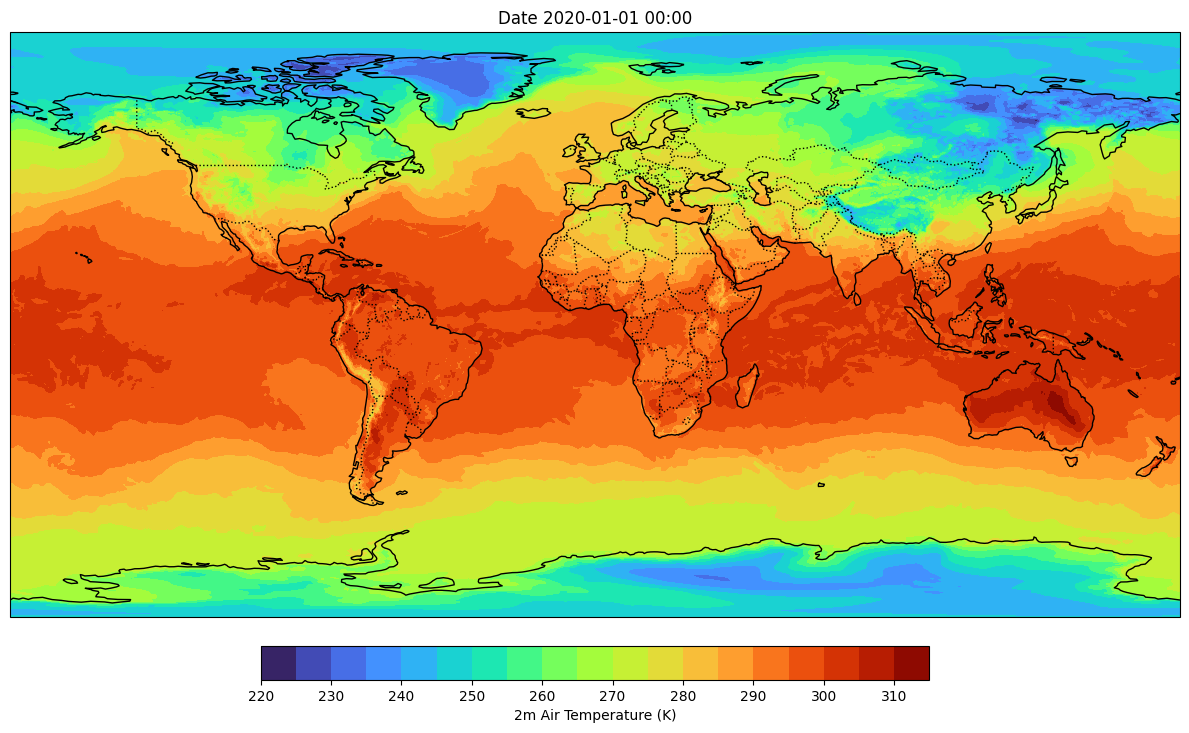

In [30]:
# Create a new figure with cartographic projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the data (longitude, latitude, values)
contourf = ax.contourf(
    t2m_data.longitude,  # X-coordinates (longitude)
    t2m_data.latitude,   # Y-coordinates (latitude)
    t2m_values,          # Temperature values
    levels=20,           # Number of color levels
    cmap='turbo',        # Color palette
    transform=ccrs.PlateCarree()  # Transform coordinates to map projection
)

# Add colorbar with proper label
cbar = plt.colorbar(
    contourf, 
    ax=ax, 
    label='2m Air Temperature (K)',
    orientation='horizontal',
    fraction=0.046,  # Controls size relative to plot
    pad=0.04         # Space between plot and colorbar
)

# Add geographic features
ax.coastlines()              # Add coastline
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')  # Add country borders

# Add title with formatted date
plt.title(f'Date {ds_era5.time[0].dt.strftime("%Y-%m-%d %H:%M").values}')

# Ensure tight layout and display
plt.tight_layout()
plt.show()

#### Key Visualization Insights
| Component | Why It Matters | What You'll See |
|----------|----------------|----------------|
| **`contourf`** | Creates color-filled polygons | Temperature gradient across globe |
| **`transform=ccrs.PlateCarree()`** | Tells Cartopy how to interpret coordinates | Data aligns correctly on world map |
| **Colorbar** | Provides quantitative context | Scale from -20°C (blue) to 30°C (red) |
| **Coastlines** | Adds geographic context | Land/sea boundaries |
| **Title** | Shows temporal information | Exact date/time of data |

### Plotting CERRA Relative Humidity
CERRA uses a rotated grid (common in regional models), so we must:

 1. Use x and y coordinates instead of longitude/latitude
 2. Understand the differences in data structure

In [33]:
# Get first time step from CERRA dataset
r2_data = ds_cerra['r2'].isel(time=0)  # First time slice
r2_values = r2_data.values  # Convert to NumPy array
print(ds_cerra)
print(r2_data)

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 248, y: 1069, x: 1069)
Coordinates:
  * time               (time) object 2kB 2020-01-01 00:00:00 ... 2020-01-31 2...
    valid_time         (time) object 2kB ...
    latitude           (y, x) float64 9MB ...
    longitude          (y, x) float64 9MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    r2                 (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-09-21T12:00 GRIB to CDM+CF via cfgrib-0.9.1...
<xarray.DataArray 'r2' (y: 1069, x: 1069)> Size: 5MB
array([[52.26758 , 51.9375  , 51.583984, ..., 39.992188, 39.67578 , 39.73047 ],
       [52.06836 , 51.703125, 51.39453 , ..., 39.98242 , 39.

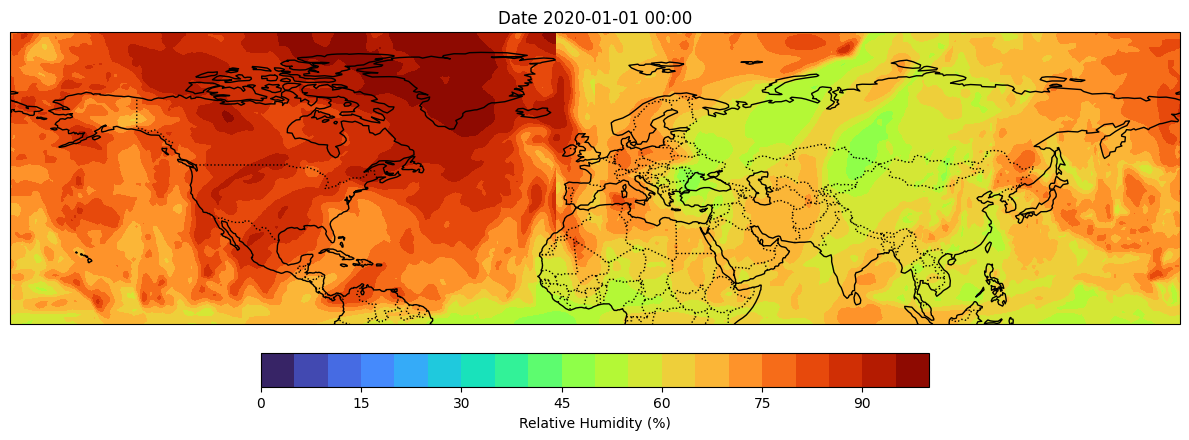

In [35]:

# Create map with same structure as ERA5
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot using CERRA's coordinate system
contourf = ax.contourf(
    r2_data.x,          # CERRA's X coordinates
    r2_data.y,          # CERRA's Y coordinates
    r2_values,
    levels=20,
    cmap='turbo',
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbar = plt.colorbar(contourf, 
                    ax=ax, 
                    label='Relative Humidity (%)',
                    orientation='horizontal',
                    fraction=0.046, 
                    pad=0.04)

# Add geographic features
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')

# Add formatted date title
plt.title(f'Date {ds_cerra.time[0].dt.strftime("%Y-%m-%d %H:%M").values}')

# Display
plt.tight_layout()
plt.show()

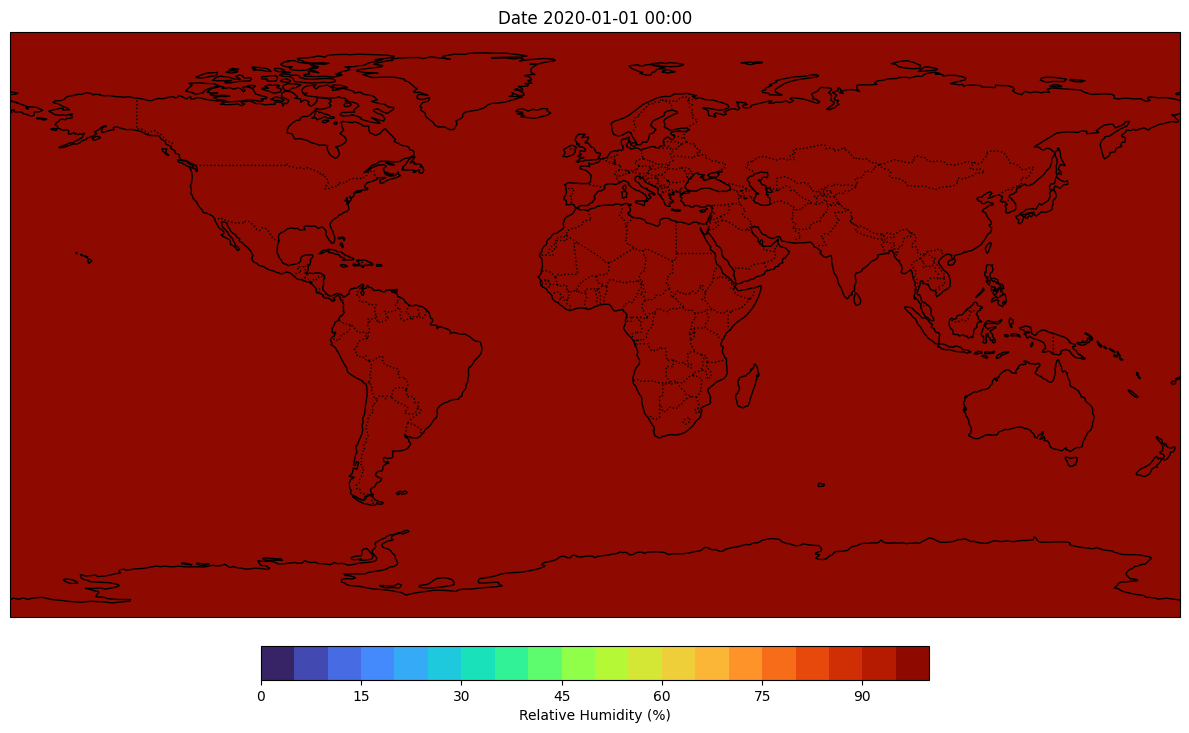

In [36]:
# Create map with same structure as ERA5
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot using CERRA's coordinate system
contourf = ax.contourf(
    r2_data.longitude,          # CERRA's longitude coordinates
    r2_data.latitude,          # CERRA's latitude coordinates
    r2_values,
    levels=20,
    cmap='turbo',
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbar = plt.colorbar(contourf, 
                    ax=ax, 
                    label='Relative Humidity (%)',
                    orientation='horizontal',
                    fraction=0.046, 
                    pad=0.04)

# Add geographic features
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')

# Add formatted date title
plt.title(f'Date {ds_cerra.time[0].dt.strftime("%Y-%m-%d %H:%M").values}')

# Display
plt.tight_layout()
plt.show()

### Critical Differences from ERA5

 Coordinate names:  
 - ERA5: longitude, latitude (regular grid)
 - CERRA: x, y (rotated grid)
     
### Why it matters? 
CERRA's grid is rotated but geographically projecte. longitude/latitude coordinates already align with Earth's surface. These aren't grid coordinates (like x, y), but georeferenced latitude/longitude—meaning they already represent actual geographic positions on Earth.  

| Dataset | Type | Coordinate Use | Result |
|---------|------|----------------|--------|
| **ERA5** | Regular grid | `longitude`, `latitude` | Works with `contourf` |
| **CERRA** | Rotated grid | `longitude`, `latitude` | Works with `pcolormesh` |

### Creating plot from curvilinear grid

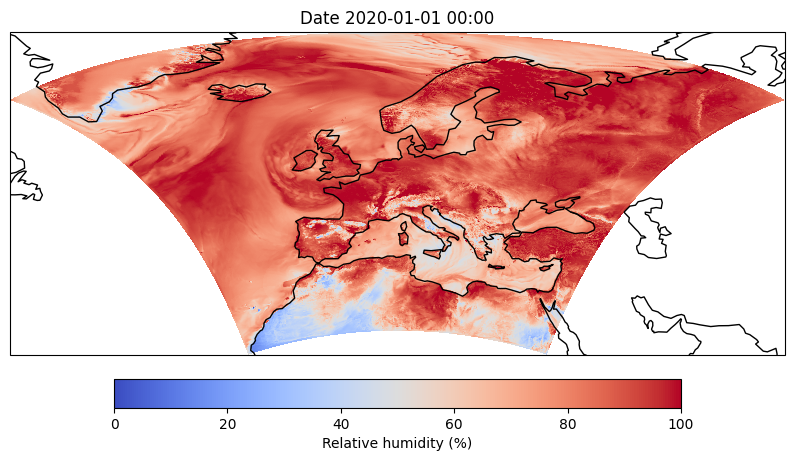

In [37]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot using pcolormesh for curvilinear grids
pcm = ax.pcolormesh(
    ds_cerra.longitude,       # CERRA's longitude
    ds_cerra.latitude,        # CERRA's latitude
    ds_cerra.r2.isel(time=0),  # First time step
    transform=ccrs.PlateCarree(),
    shading="auto",     # Better color interpolation
    cmap='coolwarm'
)

cbar = plt.colorbar(pcm, ax=ax, label='Relative humidity (%)', orientation='horizontal', fraction=0.046, pad=0.04)

ax.coastlines()

plt.title(f'Date {ds_cerra.time[0].dt.strftime("%Y-%m-%d %H:%M").values}')
plt.show()

### Common Issues and Solutions
| Problem | Cause | Solution |
|---------|-------|----------|
| **Maps with missing data** | Incorrect coordinate variables | Check if you're using `x`/`y` vs. `longitude`/`latitude` |
| **Colors out of range** | Missing data or incorrect units | Use `.dropna()` or convert units (e.g., K → °C) |
| **Map appears stretched** | Wrong coordinate projection | Always include `transform=ccrs.PlateCarree()` |

### Best Practices

1. Add geographic features (coastlines, borders)
2. Use appropriate color scales for your data type
   - turbo works well for temperature
   - coolwarm for relative humidity
3. Label colorbars with units (e.g., K, %)
4. Format titles to show temporal context